In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
from sklearn.metrics.cluster import adjusted_rand_score
from SpaNCMG import Mix_SpaNCMG
from Train import train_SpaNCMG
from Mix_adj import Transfer_pytorch_Data, Mix_adj
from lib_3d_OT.utils import *

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



In [2]:
adata=sc.read_visium('/home/dbj/mouse/DLPFC/DLPFC/151674/')
adata.var_names_make_unique()
truth = pd.read_csv('/home/dbj/mouse/vision/spatial/DLPFC_annotations/151674_truth.csv', sep='\t', index_col=0)

adata.obs['truth'] = truth.iloc[:,0]
adata = adata[~adata.obs['truth'].isna(), :]
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
Mix_adj(adata, k_cutoff=6,rad_cutoff=150)

In [3]:
adata = train_SpaNCMG(adata,n_epochs=1000) 
print("Completion of training")
sc.pp.neighbors(adata, use_rep='SpaNCMG')
sc.tl.umap(adata)

Size of Input:  (3634, 3000)
Begin to train ST data...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:25<00:00, 39.25it/s]


Completion of training


In [7]:
clustering(adata, n_clusters=7, radius=50, key='X', method='mclust', refinement=True,random=2023,n_comp=20)

fitting ...
  |======================================================================| 100%


In [8]:
adata.obs['SpaNCMG']=adata.obs['3d-OT']

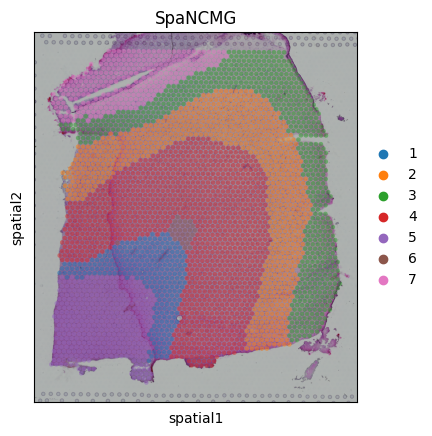

In [9]:
sc.pl.spatial(adata, color='SpaNCMG', img_key='hires', alpha=0.5, size=1.3)

In [10]:
from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score
ari = adjusted_rand_score(adata.obs['truth'], adata.obs['SpaNCMG'])
nmi = normalized_mutual_info_score(adata.obs['truth'], adata.obs['SpaNCMG'])
ari,nmi

(0.4982182344992959, 0.6850351389232765)